In [60]:
import json
import sys
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt
from statistics import mean
from matplotlib.ticker import FuncFormatter
from numpy.lib.stride_tricks import sliding_window_view
import ipywidgets as widgets
import itertools
import matplotlib.transforms as transforms
import glob
import json
from scipy.sparse import coo_matrix
import fileinput

In [61]:
# HACK, import flex-to-json.py as a module
import importlib
import os
parse_dir = os.path.join('..', 'parse')
sys.path.append(parse_dir)
flex_to_json = importlib.import_module("flex-to-json")

# Global constants

In [62]:
SENSOR_ARRAY_DIM = 24
MAX_FORCE_VALUE=10000

In [63]:
sensel_indices = list(
    itertools.product(
        range(0, SENSOR_ARRAY_DIM),
        range(0, SENSOR_ARRAY_DIM)
    ))

# Loading and converting

In [64]:
SUSPECT_SENSEL_1 = (1, 1)
SUSPECT_SENSEL_2 = (2, 2)
SUSPECT_VALUE = 1
SUSPECT_SAMPLE_COUNT = 4
            
def drop_array_indices(arr, indices):
    for ix in sorted(indices, reverse=True):
        arr.pop(ix)

    return arr

# Removes: the weird "trailing" sensor readings that seem to be present in all
# Sensing Tex output.
def remove_invalid_trailing_readings(sample, verbose=False):
    suspect_readings = {(sensel, SUSPECT_VALUE) for sensel in [SUSPECT_SENSEL_1, SUSPECT_SENSEL_2]}
    num_sensels = len(sample['vals'])
    bad_sample_ids = []

    def get_by_index(i):
        return ((sample['cols'][i], sample['rows'][i]), sample['vals'][i])
        
    for i in range(max(0, num_sensels - SUSPECT_SAMPLE_COUNT), num_sensels):
        reading = get_by_index(i)
        if reading in suspect_readings:
            bad_sample_ids.append(i)
    
    if verbose:
        print(f"Removing bad samples at indices {bad_sample_ids}: {[get_by_index(ix) for ix in bad_sample_ids]}")

    for arr in sample.values():
        drop_array_indices(arr, bad_sample_ids)

    return sample

In [65]:
def sample_to_matrix(sample):
    rows = sample['rows']
    cols = [SENSOR_ARRAY_DIM - 1 - c for c in sample['cols']]
    vals = np.array(sample['vals'])
    # TODO: work with coo_matrices instead of dense arrays?
    return coo_matrix((vals, (rows, cols)), shape=(SENSOR_ARRAY_DIM, SENSOR_ARRAY_DIM), dtype=np.uint16).toarray()

def values_are_in_range(sample):
    return all((r >= 0 and r < SENSOR_ARRAY_DIM for r in sample['rows'])) and \
           all((c >= 0 and c < SENSOR_ARRAY_DIM for c in sample['cols'])) and \
           all((v >= 0 and v <= MAX_FORCE_VALUE for v in sample['vals']))

## Converts rec in dict form to rec in matrix form 
def convert_json_rec(rec, fix_issues=True):
    timestamps = rec['timestamps']

    samples = rec['samples']
    
    if fix_issues:            
        indices_of_oor_samples = [ix for ix, s in enumerate(samples) if not values_are_in_range(s)]
        if indices_of_oor_samples:
            print(f"Dropping samples {indices_of_oor_samples} due to out-of-range values")
        samples = drop_array_indices(samples, indices_of_oor_samples)
        timestamps = drop_array_indices(timestamps, indices_of_oor_samples)

        samples = map(remove_invalid_trailing_readings, samples)
    
    matrix = map(sample_to_matrix, samples)

    metadata = rec.get('metadata')    
    data = [{'millis': t, 'measurements': m} for (t, m) in zip(timestamps, matrix)]
    return {'data': data, 'metadata': metadata}

# Loads a JSON file that was obtained by converting using
# flex-to-json.py
def load_json_rec(json_file, fix_issues=True):
    with open(json_file) as jf:
        rec = json.load(jf)

        return convert_json_rec(rec, fix_issues=fix_issues)

# Loads a "raw" .dat recording by first converting it into
# JSON using flex-to-json.py
def load_dat_rec(dat_file, fix_issues=True):
    with fileinput.input(dat_file) as inp:
        rec = flex_to_json.parse_flex_recording(inp)      
    
    return convert_json_rec(rec, fix_issues=fix_issues)

# Demo recording

In [105]:
REC_FILE = "../../rec/flex/workshop/V5_MAT_ROLL/bottle-roll-adc-16.dat"

In [106]:
219

219

In [107]:
DEMO_TRACE = load_dat_rec(REC_FILE, fix_issues=True)
DEMO_TRACE = DEMO_TRACE['data']

# Sample heatmap

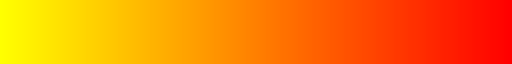

In [108]:
mpl.cm.autumn_r

In [109]:
def plot_heatmap(matrix, figsize=(5,5)):
    fig, ax = plt.subplots(figsize=figsize)
    # colors = [mpl.cm.autumn_r(i/MAX_FORCE_VALUE) for i in range(0, MAX_FORCE_VALUE)]
    # colors[0] = (1, 1, 1, 1)

    # cmap = mpl.colors.LinearSegmentedColormap.from_list("cm_with_zero", colors=colors)
    
    im = ax.imshow(matrix.T, vmin=0, vmax=MAX_FORCE_VALUE) #, cmap=cmap)
    ax.grid()
    ax.set_xlim(0, SENSOR_ARRAY_DIM-1)
    ax.set_ylim(SENSOR_ARRAY_DIM-1, 0)
    ax.set_xticks(list(range(0, SENSOR_ARRAY_DIM, round(SENSOR_ARRAY_DIM/4))))
    ax.set_yticks(list(reversed(range(0, SENSOR_ARRAY_DIM, round(SENSOR_ARRAY_DIM/4)))))

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    return (fig, ax)

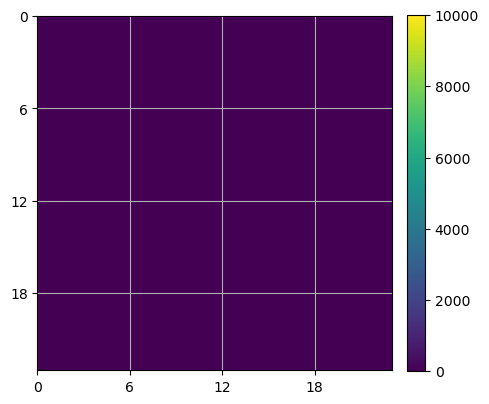

In [110]:
_ = plot_heatmap(DEMO_TRACE[230]['measurements'])

In [111]:
def heatmap_widget(trace):
    w = widgets.IntSlider(value=0, min=0, max=len(trace)-1, description="Sample ID")
    _ = widgets.interact(lambda t: plot_heatmap(trace[t]['measurements'], figsize=(10, 10)), t=w)

heatmap_widget(DEMO_TRACE)

interactive(children=(IntSlider(value=0, description='Sample ID', max=3801), Output()), _dom_classes=('widget-…

# Force reading histograms

In [112]:
# [(millis, f)] for a specific sensel at (col, row) higher than (optional) min_val
# TODO: convert to col=col, row=row kwargs to avoid confusion
def sensel_series(trace, row, col, min_val=-1):
    return [(s['millis'], s['measurements'][col][row]) for s in trace if s['measurements'][col][row] > min_val]    

In [113]:
def truncate_sensel_series(series):
    def drop_zeroes(iterable):
        return list(itertools.dropwhile(lambda s: s[1] == 0, iterable))
    drop_front = drop_zeroes(series)
    drop_back = drop_zeroes(reversed(drop_front))
    return list(reversed(drop_back))

In [114]:
def all_sensel_readings(trace):
    readings = np.array([])
    measurements = [s['measurements'] for s in trace]
    for m in measurements:
        all_readings = m.flat
        readings = np.concatenate((readings, all_readings[all_readings > 0]))
    return readings

In [115]:
def plot_reading_hist(trace):
    trace_readings = all_sensel_readings(trace)
    ax = plt.subplot()
    _ = ax.hist(trace_readings, bins=255)
    ax.set_title("Histogram of individual sensel readings")
    ax.set_ylabel("Number of samples containing the value")
    ax.set_xlabel(f"Force reading")
    return ax

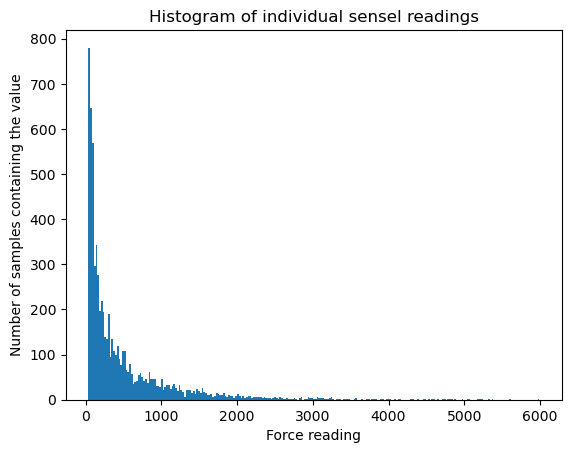

In [116]:
_ = plot_reading_hist(DEMO_TRACE)

(0.0, 60.0)

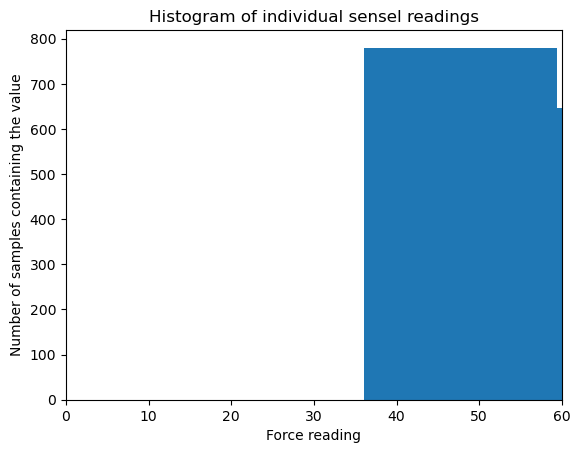

In [117]:
ax = plot_reading_hist(DEMO_TRACE)
ax.set_xlim(0, 60)

# Sensel force ranges

In [118]:
def plot_sensel_min_max_vals(trace):
    sensel_mins = np.repeat(np.nan, 24*24).reshape((SENSOR_ARRAY_DIM, SENSOR_ARRAY_DIM))
    sensel_maxes = np.repeat(np.nan, 24*24).reshape((SENSOR_ARRAY_DIM, SENSOR_ARRAY_DIM))

    for (row, col) in sensel_indices:
        max_v = None
        min_v = None
        for _, v in sensel_series(trace, row, col, 0):
            max_v = max(v, max_v) if max_v is not None else v
            min_v = min(v, min_v) if min_v is not None else v
    
        sensel_mins[row, col] = min_v
        sensel_maxes[row, col] = max_v

    _, ax = plot_heatmap(sensel_mins)
    ax.set_title("Sensel observed minimums")

    _, ax = plot_heatmap(sensel_maxes)
    ax.set_title("Sensel observed maximums")

    return (sensel_mins, sensel_maxes)
    

In [119]:
np.sum(np.isnan(mins))

45

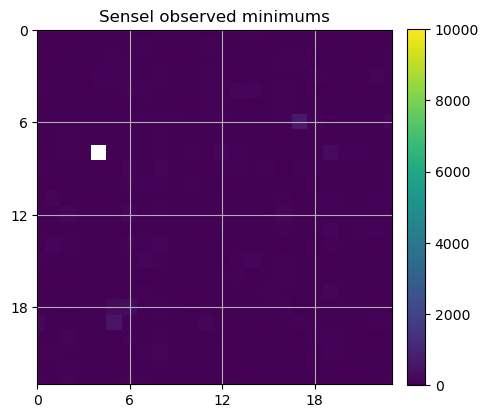

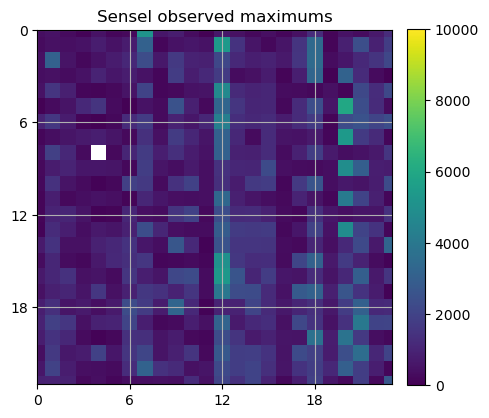

In [120]:

mins, maxes = plot_sensel_min_max_vals(DEMO_TRACE)

In [123]:
potentially_dead_sensels = set(tuple(i) for i in np.argwhere(np.isnan(mins)))

In [124]:
potentially_broken_sensels = set(tuple(i) for i in np.concatenate((np.argwhere(mins > 30), np.argwhere(maxes < 30))))

In [125]:
potentially_dead_sensels

{(4, 8)}

## Sampling rate change/stability

In [22]:
def trace_millis(trace):
    return [s['millis'] for s in trace]

In [23]:
def millis_to_durations(millis):
    return np.pad(np.diff(millis), (1, 0))

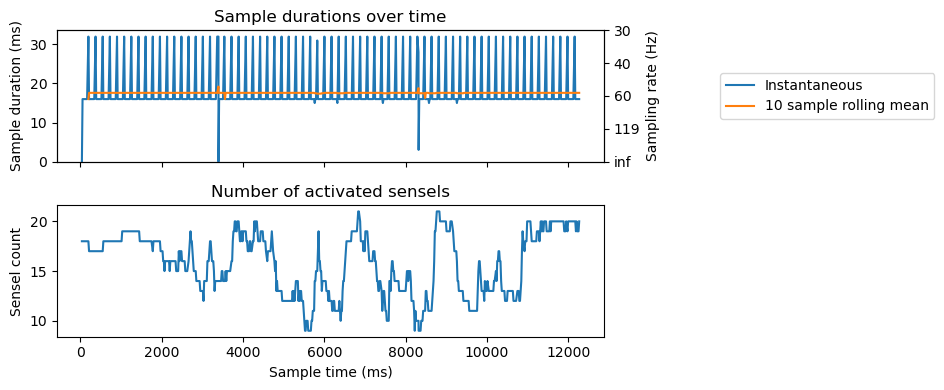

In [24]:
def plot_sampling_intervals(trace):
    #trace = full_trace[100:150]
    millis = trace_millis(trace)
    activation_counts = [(s['measurements'].flat > 0).sum() for s in trace]
    durs = millis_to_durations(millis)
    
    window = 10
    durs_v_10 = sliding_window_view(durs, window)
    
    fig, [ax, ax2] = plt.subplots(2, 1, sharex=True, figsize=(10,4))
    ax.plot(millis, durs, label="Instantaneous")
    #ax.plot(millis[window-1:], durs_v_10.min(axis=-1), label="10 sample rolling min")
    ax.plot(millis[window-1:], durs_v_10.mean(axis=-1), label="10 sample rolling mean")
    #ax.plot(millis[window-1:], durs_v_10.max(axis=-1), label="10 sample rolling max")
    
    ax.set_ylim(bottom=0)
    
    ax.set_ylabel("Sample duration (ms)")
    
    ax_twin = ax.twinx()
    _, ymax = ax.get_ylim()
    ax_twin.set_ylabel("Sampling rate (Hz)")
    ax_twin.yaxis.set_major_formatter(FuncFormatter(lambda x,pos: f"{((1000.0/(x*ymax)) if x > 0 else np.Infinity):.0f}"))
    
    
    
    ax.set_title("Sample durations over time")
    ax.legend(loc='center left', bbox_to_anchor=(1.2, 0.5))
    
    ax2.set_xlabel("Sample time (ms)")
    ax2.plot(millis, activation_counts, label="Activation counts")
    ax2.set_title("Number of activated sensels")
    ax2.set_ylabel("Sensel count")
    fig.tight_layout()
    plt.show()

plot_sampling_intervals(DEMO_TRACE)

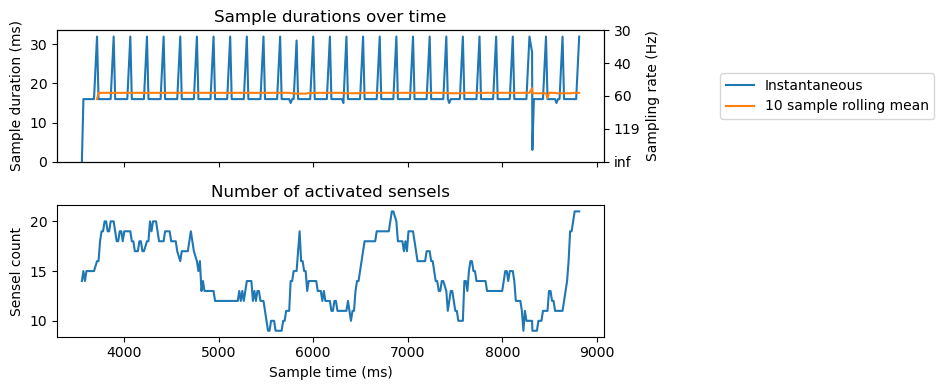

In [25]:
plot_sampling_intervals(DEMO_TRACE[200:500])

# Single sensel force series

In [26]:
def observed_minimum_series(point_series):
    cur_minimum = 0
    points = []
    for t, v in point_series:
        if cur_minimum == 0:
            cur_minimum = v
            
        if v > 0:
            cur_minimum = min(v, cur_minimum)
    
        points.append((t, cur_minimum))
        
    return points

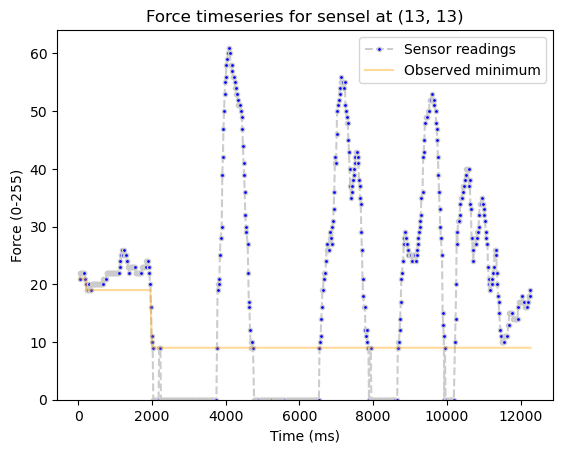

In [27]:
# %matplotlib widget
# import matplotlib.pyplot as plt 
def plot_point_force(trace, row, col):
    point_series = truncate_sensel_series(sensel_series(trace, row, col, -9999))
    if len(point_series) == 0:
        print("All zeroes, nothing to plot")
        return

    fig, ax = plt.subplots()
    min_series = observed_minimum_series(point_series)
    ax.plot(*zip(*point_series), color='0.8', markerfacecolor='blue', linestyle='--', marker='.', label="Sensor readings")
    ax.plot(*zip(*min_series), color='orange', alpha=0.4, linestyle='-', label="Observed minimum")
    ax.set_ylim(bottom=0.0)
    ax.set_title(f"Force timeseries for sensel at ({col}, {row})")
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Force (0-255)")
    ax.legend()
    plt.show()


plot_point_force(DEMO_TRACE, 13, 13)

In [28]:
def force_series_widget(trace):
    w_row = widgets.IntSlider(value=0, min=-(SENSOR_ARRAY_DIM - 1), max=0, orientation='vertical')
    w_col = widgets.IntSlider(value=0, min=0, max=(SENSOR_ARRAY_DIM - 1))
    _ = widgets.interact(lambda row, col: plot_point_force(trace, -1*row, col), row=w_row, col=w_col)


force_series_widget(DEMO_TRACE)


interactive(children=(IntSlider(value=0, description='row', max=0, min=-23, orientation='vertical'), IntSlider…

# Observed minimum convergence towards real minimum

In [29]:
def plot_observed_minimum_series(trace):
    point_times =  { (i,j): [] for (i,j) in itertools.product(range(0, SENSOR_ARRAY_DIM), range(0, SENSOR_ARRAY_DIM)) }
    point_values = { (i,j): [] for (i,j) in itertools.product(range(0, SENSOR_ARRAY_DIM), range(0, SENSOR_ARRAY_DIM)) }
    
    for sample in trace:
        millis = sample['millis']
        m = sample['measurements']
        rows, cols = np.nonzero(m)
        points = zip(rows, cols)
        for (i, j) in points:
            point_times[(i, j)].append(millis)
            # could actually avoid copying this and just store the times+indices
            point_values[(i, j)].append(m[i][j])
    
    MIN_SAMPLE_THRESHOLD=10
    QUICK_CONVERGE_TIME_MS=1000
    QUICK_CONVERGE_VALUE=10
    
    def observed_min_view(series):
        cur_min = 256
        for v in series:
            if v < cur_min:
                cur_min = v
            yield cur_min
    
    print(f"Total number of sensels activated: {sum([1 for p in point_times if len(point_times[p]) > 0])}")
    
    for p in list(point_times):
        if len(point_times[p]) < MIN_SAMPLE_THRESHOLD:
            del point_times[p]
            del point_values[p]
    
    print(f"Total number of sensels with more than {MIN_SAMPLE_THRESHOLD} samples: {len(point_times)}")
    
    num_converged = 0
    for p in list(point_times):
        first_sample_time = point_times[p][0]
        for ix, t in enumerate(point_times[p]):
            if (t - first_sample_time) > QUICK_CONVERGE_TIME_MS:
                break
            else:
                if point_values[p][ix] <= QUICK_CONVERGE_VALUE:
                    del point_times[p]
                    del point_values[p]
                    num_converged += 1
                    break
    
    print(f"Total number of sensels that quickly (in {QUICK_CONVERGE_TIME_MS}ms since first sample) converged close to real minimum ({QUICK_CONVERGE_VALUE}): {num_converged}")
    print(f"Total number of sensels that failed to converge quickly: {len(point_values)}")

    
    fig, ax = plt.subplots(figsize=(10, 10))
    
    for p in list(point_times):
        ax.plot(point_times[p], list(observed_min_view(point_values[p])), label=f"{p}",
                 linestyle="--", alpha=0.6, marker='.')

    ax.set_title("Sensels failing to quickly convergence towards real minimum")
    ax.set_ylabel("Observed minimum force")
    ax.set_xlabel("Time (ms)")
    ax.axhline(9, label="Real minimum", linestyle="-.", color="black")
    trans = transforms.blended_transform_factory(ax.get_yticklabels()[0].get_transform(), ax.transData)
    ax.text(0, 9, "Real minimum", transform=trans, ha="right", va="center")
    None

Total number of sensels activated: 71
Total number of sensels with more than 10 samples: 68
Total number of sensels that quickly (in 1000ms since first sample) converged close to real minimum (10): 38
Total number of sensels that failed to converge quickly: 30


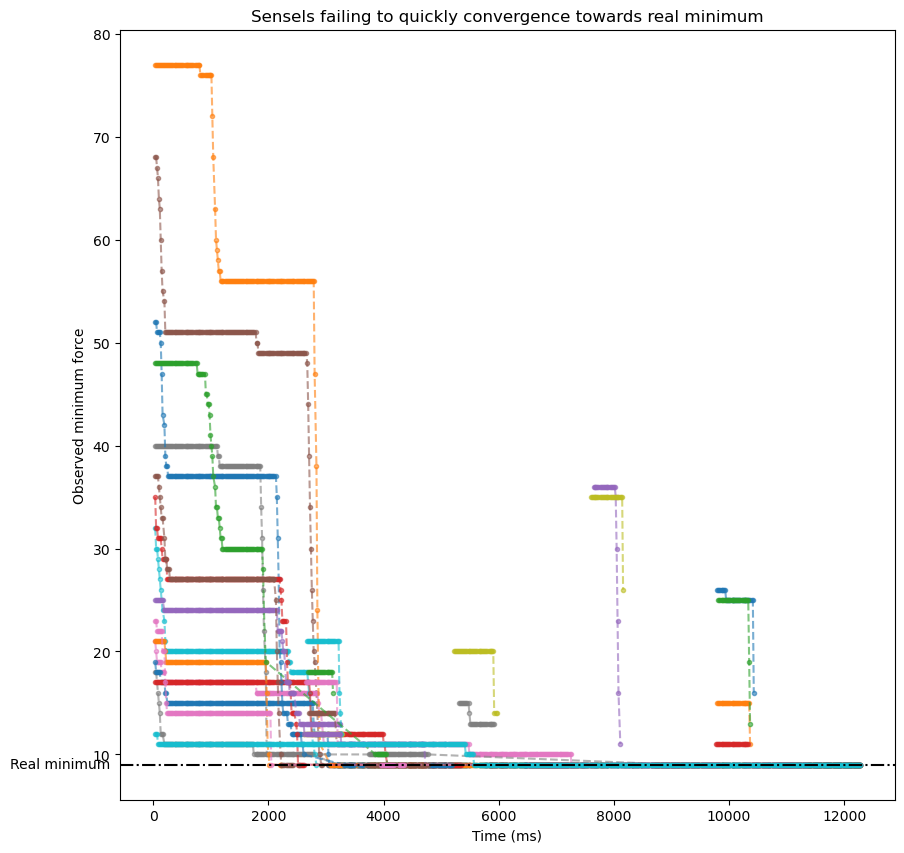

In [30]:
plot_observed_minimum_series(DEMO_TRACE)

## Interactive plot-everything

In [31]:
all_trace_files = glob.glob("../../rec/flex/*.dat")

In [32]:
def analyze_trace(trace):
    plot_reading_hist(trace)
    plot_sampling_intervals(trace)
    heatmap_widget(trace)
    force_series_widget(trace)
    plot_observed_minimum_series(trace)

def load_and_analyze_trace(trace_file, sample_range):
    loaded = load_dat_rec(trace_file)['data']
    (start_pct, end_pct) = sample_range
    start = start_pct/100 * len(loaded)
    end = end_pct/100 * len(loaded)
    analyze_trace(loaded[int(start):int(end)])

In [33]:
w_file = widgets.Dropdown(options=all_trace_files)
w_range = widgets.IntRangeSlider(min=0, max=100, value=[0, 100], description="Sample range (%)")
widgets.interact(load_and_analyze_trace, trace_file=w_file, sample_range=w_range)

interactive(children=(Dropdown(description='trace_file', options=('../../rec/flex/two-vals.dat', '../../rec/fl…

<function __main__.load_and_analyze_trace(trace_file, sample_range)>